In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import datetime as dt

df = pd.read_csv("/Users/adronallen/Downloads/data.csv",encoding="latin1")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Cancellations are marked with InvoiceNo starting with 'C' — these are returns, not standard losses
df['IsCancellation'] = df['InvoiceNo'].astype(str).str.startswith('C')
print(f"Cancellations: {df['IsCancellation'].sum()} rows ({df['IsCancellation'].mean()*100:.1f}%)")

Cancellations: 9288 rows (1.7%)


In [6]:
# CustomerID is missing for ~25% of rows in this dataset — these are likely guest checkouts
print(f"Missing CustomerID: {df['CustomerID'].isnull().sum()} rows ({df['CustomerID'].isnull().mean()*100:.1f}%)")

# Drop rows with no CustomerID for any customer-level analysis (keep a separate df for that)
df_customers = df.dropna(subset=['CustomerID']).copy()

Missing CustomerID: 135080 rows (24.9%)


In [7]:
# Check for exact duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicate rows: 5268


In [8]:
# Standardize product descriptions to avoid splitting the same product across groups
df['Description'] = df['Description'].str.strip().str.upper()

In [9]:
df['Quantity'].describe()

count    536641.000000
mean          9.620029
std         219.130156
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [10]:
top_5 = df.groupby('InvoiceNo')['Quantity'].sum().sort_values(ascending=False).head(5)
top_5

InvoiceNo
581483    80995
541431    74215
556917    15049
563076    14730
574941    14149
Name: Quantity, dtype: int64

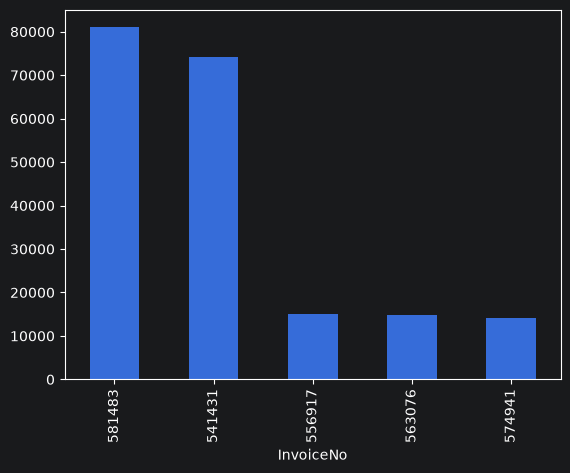

In [11]:
top_5.plot.bar()
plt.show()

In [12]:
df[df['InvoiceNo']== '581483']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,False


Potential company purchase

In [13]:
# Creating new column in order to compare Invoice order totals
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
df.groupby('InvoiceNo')['TotalPrice'].sum().sort_values(ascending=False).head(3)

InvoiceNo
581483    168469.60
541431     77183.60
574941     52940.94
Name: TotalPrice, dtype: float64

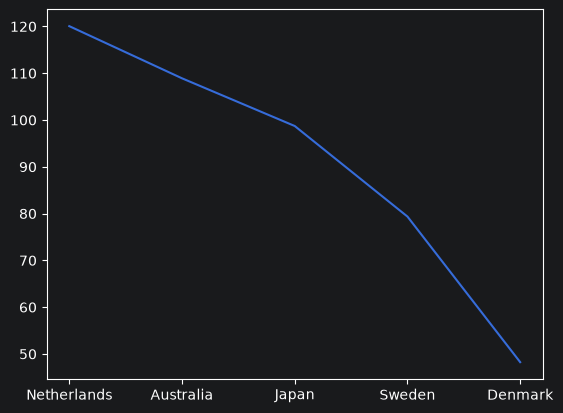

In [15]:
country_top_5 = df.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False).head(5)
plt.plot(country_top_5)
plt.show()

In [16]:
#Investigating negative Total Priced
df[df['TotalPrice'] < 0].sort_values(by='TotalPrice',ascending=True).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,TotalPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12/9/2011 9:27,2.08,16446.0,United Kingdom,True,-168469.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom,True,-77183.60
222681,C556445,M,MANUAL,-1,6/10/2011 15:31,38970.00,15098.0,United Kingdom,True,-38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,12/5/2011 11:36,17836.46,NaN,United Kingdom,True,-17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,1/5/2011 9:55,16888.02,NaN,United Kingdom,True,-16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,1/5/2011 9:57,16453.71,NaN,United Kingdom,True,-16453.71
16356,C537651,AMAZONFEE,AMAZON FEE,-1,12/7/2010 15:49,13541.33,NaN,United Kingdom,True,-13541.33
15016,C537630,AMAZONFEE,AMAZON FEE,-1,12/7/2010 15:04,13541.33,NaN,United Kingdom,True,-13541.33
16232,C537644,AMAZONFEE,AMAZON FEE,-1,12/7/2010 15:34,13474.79,NaN,United Kingdom,True,-13474.79
524601,C580604,AMAZONFEE,AMAZON FEE,-1,12/5/2011 11:35,11586.50,NaN,United Kingdom,True,-11586.50


In [17]:
# observing losses by Product
losses = df[df['TotalPrice'] < 0]
losses_by_product = losses.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)
losses_by_product

Description
HANGING WOOD AND FELT FLOWER              -0.12
STARS GIFT TAPE                           -0.19
RECYCLED PENCIL WITH RABBIT ERASER        -0.21
FRENCH STYLE STORAGE JAR JAM              -0.29
STRIPY DESIGN SHOWER CAP                  -0.29
                                        ...    
ADJUST BAD DEBT                       -22124.12
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
MANUAL                               -146784.46
PAPER CRAFT , LITTLE BIRDIE          -168469.60
AMAZON FEE                           -235281.59
Name: TotalPrice, Length: 1972, dtype: float64

Examining Major Losses

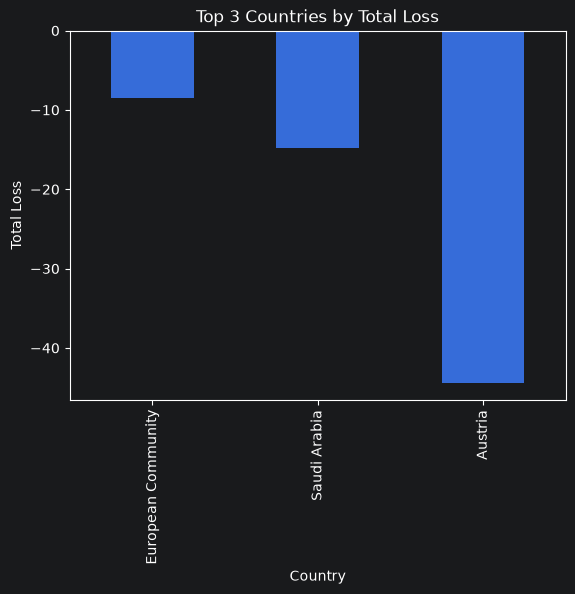

In [18]:
# biggest losses by country
losses_by_country = losses.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(3)

losses_by_country.plot.bar()
plt.xlabel('Country')
plt.ylabel('Total Loss')
plt.title('Top 3 Countries by Total Loss')
plt.show()


In [19]:
country_name = 'Austria'
country_losses = losses[losses['Country'] == country_name]
losses_by_item = country_losses.groupby('Description')['TotalPrice'].sum().sort_values(ascending= True)
losses_by_item.head(10)

Description
KINGS CHOICE BISCUIT TIN          -21.25
ANGEL DECORATION STARS ON DRESS   -20.16
GREEN REGENCY TEACUP AND SAUCER    -2.95
Name: TotalPrice, dtype: float64

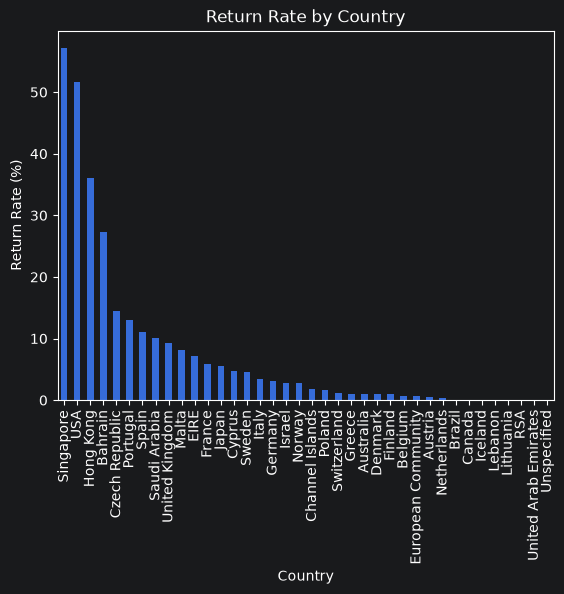

In [20]:
sales_by_country = df[df['TotalPrice'] > 0].groupby('Country')['TotalPrice'].sum()
losses_by_country = df[df['TotalPrice'] < 0].groupby('Country')['TotalPrice'].sum()

country_return_rate = (losses_by_country.abs() / sales_by_country) * 100
country_return_rate = country_return_rate.sort_values(ascending=False)

country_return_rate.plot.bar()
plt.xlabel('Country')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Country')
plt.show()

Time based patterns
Exploring Monthly, Daily and Yearly Sales

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [22]:
df[['InvoiceDate', 'Year', 'Month', 'DayOfWeek', 'Hour']].head()

,InvoiceDate,Year,Month,DayOfWeek,Hour
0,2010-12-01 08:26:00,2010,12,Wednesday,8
1,2010-12-01 08:26:00,2010,12,Wednesday,8
2,2010-12-01 08:26:00,2010,12,Wednesday,8
3,2010-12-01 08:26:00,2010,12,Wednesday,8
4,2010-12-01 08:26:00,2010,12,Wednesday,8


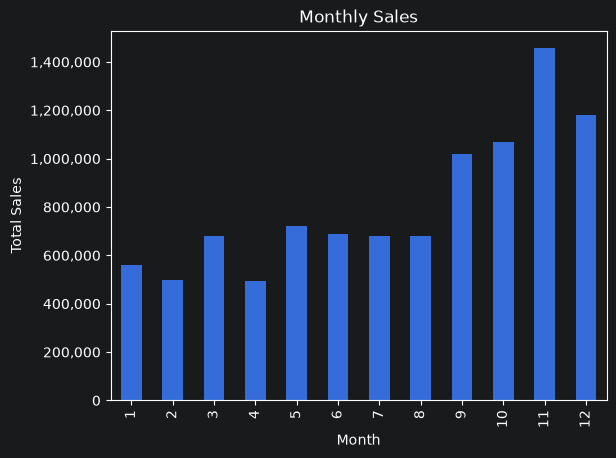

In [23]:
# Sales by Month
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
fig, ax = plt.subplots()
monthly_sales.plot.bar(ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales')
plt.show()

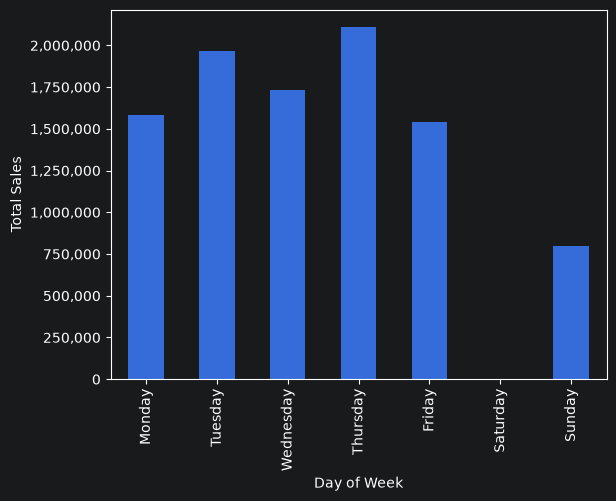

In [24]:
days_of_week = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(days_of_week)
fig, ax = plt.subplots()
daily_sales.plot.bar(ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()

Product Level Deep Dive

In [25]:
product_sales = df[df['TotalPrice'] > 0].groupby('Description')['TotalPrice'].sum()
product_losses =df[df['TotalPrice'] < 0].groupby('Description')['TotalPrice'].sum()
return_rate = (product_losses/product_sales).sort_values()

In [26]:
product_sales

Description
*BOOMBOX IPOD CLASSIC                 16.98
*USB OFFICE MIRROR BALL               16.94
10 COLOUR SPACEBOY PEN              5585.45
12 COLOURED PARTY BALLOONS          1398.51
12 DAISY PEGS IN WOOD BOX            592.62
                                     ...   
ZINC T-LIGHT HOLDER STARS SMALL     4197.83
ZINC TOP  2 DOOR WOODEN SHELF        270.08
ZINC WILLIE WINKIE  CANDLE STICK    2712.70
ZINC WIRE KITCHEN ORGANISER          239.97
ZINC WIRE SWEETHEART LETTER TRAY     275.62
Name: TotalPrice, Length: 4015, dtype: float64

In [27]:
product_losses

Description
10 COLOUR SPACEBOY PEN             -146.20
12 COLOURED PARTY BALLOONS          -13.00
12 EGG HOUSE PAINTED WOOD           -12.75
12 IVORY ROSE PEG PLACE SETTINGS     -1.25
12 MESSAGE CARDS WITH ENVELOPES      -1.65
                                     ...  
ZINC SWEETHEART WIRE LETTER RACK    -15.00
ZINC T-LIGHT HOLDER STAR LARGE      -10.45
ZINC T-LIGHT HOLDER STARS SMALL     -36.52
ZINC TOP  2 DOOR WOODEN SHELF       -76.75
ZINC WILLIE WINKIE  CANDLE STICK    -10.20
Name: TotalPrice, Length: 1972, dtype: float64

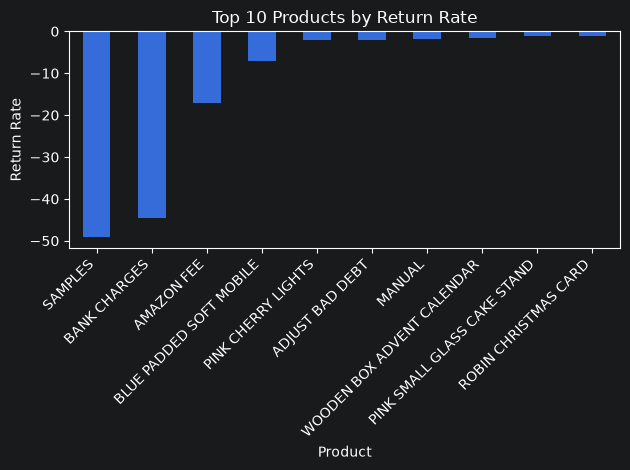

In [28]:
return_rate.head(10).plot.bar()
plt.xlabel('Product')
plt.ylabel('Return Rate')
plt.title('Top 10 Products by Return Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

RFM Segmentation


RFM scores customers on how **Recently** they purchased, how **Frequently**, and how much **Monetary** value they generated — a standard technique for identifying your best customers vs. at-risk ones.

In [29]:
df_customers = df.dropna(subset=['CustomerID']).copy()
print(df_customers.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsCancellation', 'TotalPrice', 'Year', 'Month', 'DayOfWeek', 'Hour']


In [30]:
rfm_data = df_customers[df_customers['TotalPrice'] > 0]

snapshot_date = rfm_data['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = rfm_data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [31]:
# Score each dimension 1-4 (quartiles). Lower recency = better, so it's scored in reverse.
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,7,4310.00,4,4,4,12
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,3,1,4,8
12350.0,310,1,334.40,1,1,2,4


In [32]:
# Label segments based on combined score
def segment_customer(score):
    if score >= 10:
        return 'Champion'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)
segment_counts = rfm['Segment'].value_counts()
segment_counts

Segment
Lost        1291
Champion    1267
At Risk      935
Loyal        845
Name: count, dtype: int64

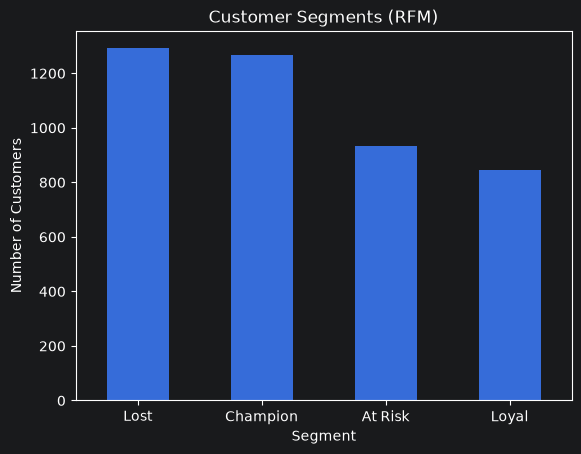

In [33]:
segment_counts.plot.bar()
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segments (RFM)')
plt.xticks(rotation=0)
plt.show()

In [34]:
# What's each segment worth?
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champion    6827235.770
Loyal       1051599.981
At Risk      650529.152
Lost         357843.991
Name: Monetary, dtype: float64